Credit Card Fraud Detection using Support Vector Machine (SVM)

In [1]:
#import library
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#Mount Drive and Read creditcard
from google.colab import drive
drive.mount('/content/drive')
credit_card_data = pd.read_csv('creditcard.csv')

Mounted at /content/drive


In [3]:
credit_card_data.keys()

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [4]:
#data information
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37722 entries, 0 to 37721
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    37722 non-null  int64  
 1   V1      37722 non-null  float64
 2   V2      37722 non-null  float64
 3   V3      37722 non-null  float64
 4   V4      37722 non-null  float64
 5   V5      37722 non-null  float64
 6   V6      37722 non-null  float64
 7   V7      37721 non-null  float64
 8   V8      37721 non-null  float64
 9   V9      37721 non-null  float64
 10  V10     37721 non-null  float64
 11  V11     37721 non-null  float64
 12  V12     37721 non-null  float64
 13  V13     37721 non-null  float64
 14  V14     37721 non-null  float64
 15  V15     37721 non-null  float64
 16  V16     37721 non-null  float64
 17  V17     37721 non-null  float64
 18  V18     37721 non-null  float64
 19  V19     37721 non-null  float64
 20  V20     37721 non-null  float64
 21  V21     37721 non-null  float64
 22

In [5]:
#check isnull
credit_card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,1
V8,1
V9,1


In [6]:
credit_card_data['Class'].value_counts()

,count
Class,
0.0,37618
1.0,103


In [7]:
#drop column time
credit_card_data = credit_card_data.drop('Time', axis=1)

In [8]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()

In [9]:
#standard scaling
credit_card_data['std_Amount'] = scaler.fit_transform(credit_card_data['Amount'].values.reshape(-1,1))

#remove Amount
credit_card_data = credit_card_data.drop('Amount', axis=1)

<Axes: xlabel='Class', ylabel='count'>

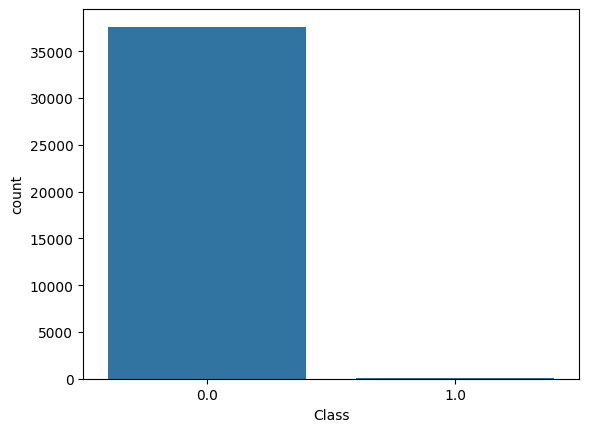

In [10]:
#plot countplot class
sns.countplot(x="Class", data=credit_card_data)
#

In [11]:
import imblearn
from imblearn.under_sampling import RandomUnderSampler

undersample = RandomUnderSampler(sampling_strategy=0.5)

In [14]:
cols = credit_card_data.columns.tolist()
cols = [c for c in cols if c not in ["Class"]]
target = "Class"

#

In [16]:
credit_card_data.dropna(subset=['Class'], inplace=True)
X = credit_card_data[cols]
Y = credit_card_data[target]

X_under, Y_under = undersample.fit_resample(X, Y)

In [17]:
from pandas import DataFrame
df_under = DataFrame(Y_under, columns=['Class'])


Text(0.5, 1.0, 'Undersampled Data')

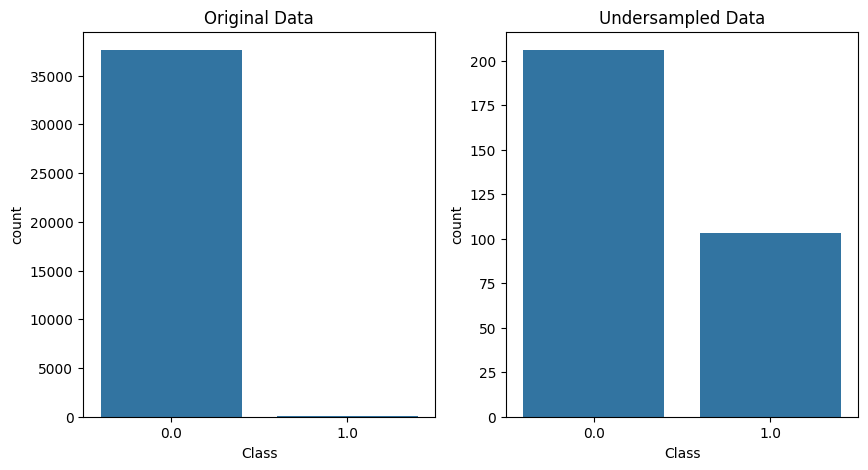

In [18]:
#Visulizing undersampling results
fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
sns.countplot(x="Class", data=credit_card_data, ax=axs[0])
sns.countplot(x="Class", data=df_under, ax=axs[1])

axs[0].set_title("Original Data")
axs[1].set_title("Undersampled Data")

## **Train Test Split**

In [34]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_under, Y_under, test_size=0.2, random_state=100)
#

# Using Support Vector Machine Model

In [35]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import classification_report

In [36]:
model = SVC()
model.fit(X_train, y_train)

SVC()

In [37]:
model2 = SVC(probability=True, random_state=42)
svm = model2.fit(X_train, y_train)

In [38]:
#predictions
y_pred_svm = model2.predict(X_test)

In [39]:
#scores
print("Accuracy Score: ", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix: ", confusion_matrix(y_test, y_pred_svm))
print("Classification Report: ", classification_report(y_test, y_pred_svm))
#

Accuracy Score:  0.9838709677419355
Confusion Matrix:  [[34  0]
 [ 1 27]]
Classification Report:                precision    recall  f1-score   support

         0.0       0.97      1.00      0.99        34
         1.0       1.00      0.96      0.98        28

    accuracy                           0.98        62
   macro avg       0.99      0.98      0.98        62
weighted avg       0.98      0.98      0.98        62



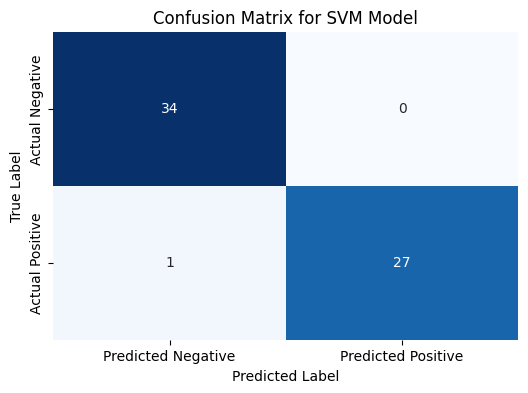

In [40]:
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix for SVM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

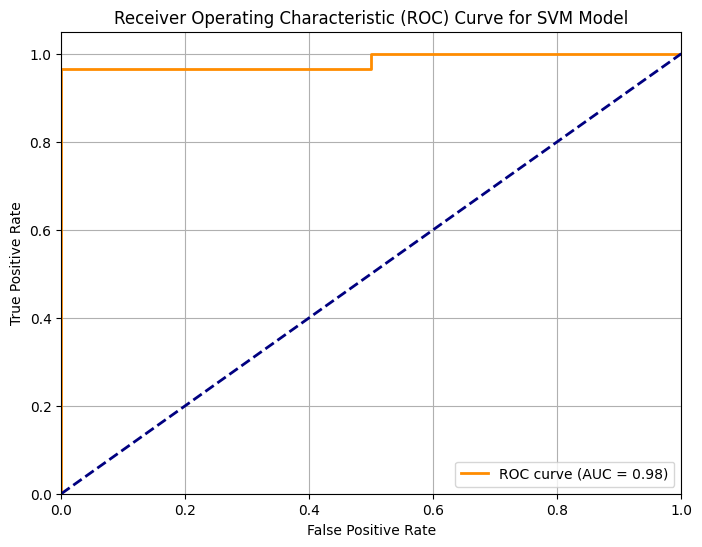

In [41]:
y_pred_proba_svm = model2.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_svm)
auc_svm = roc_auc_score(y_test, y_pred_proba_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_svm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for SVM Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()